# Forward Filtering Backward Smoothing (FFBS)

This notebook demonstrates the two FFBS algorithms for particle smoothing
in a **Stochastic Volatility (SV)** model:

- **FFBSm** (Backward Smoothing): Reweights filtering particles using backward recursion.
  Complexity O(T·N²).
- **FFBSi** (Backward Simulation): Generates M independent smoothed trajectories by
  backward sampling. Complexity O(T·N·M).

We compare filtered vs smoothed estimates, analyze the variance reduction (smoothing gain),
and discuss the trade-offs between the two algorithms.

**References:**
- Godsill, Doucet & West (2004). *Monte Carlo smoothing for nonlinear time series.* JASA.
- Lindsten & Schön (2013). *Backward simulation methods for Monte Carlo statistical inference.*


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass, field
import time
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Import particlefilterbox smoothers
from particlefilterbox.smoothers import FFBSm, FFBSi


In [2]:
# Load simulated SV data
data_path = Path('..') / 'data' / 'simulated_sv.csv'
df_full = pd.read_csv(data_path)

# Use first 100 observations for manageable FFBSm runtime (O(T*N^2))
T_USE = 100
df = df_full.iloc[:T_USE].reset_index(drop=True)
y_obs = df['y_obs'].values
h_true = df['h_true'].values
T = len(y_obs)
print(f"Using T = {T} observations (from {len(df_full)} total)")
print(df.head())


Using T = 100 observations (from 1000 total)
   t    h_true     y_obs
0  0 -0.811984 -0.692957
1  1 -0.705057  0.661131
2  2 -1.006561 -0.787225
3  3 -0.987188 -0.193044
4  4 -0.990092 -0.519967


## Mathematical Background

### Stochastic Volatility Model

$$h_t = \mu + \phi(h_{t-1} - \mu) + \sigma_\eta \eta_t, \quad \eta_t \sim N(0,1)$$
$$y_t = \exp(h_t / 2)\,\varepsilon_t, \quad \varepsilon_t \sim N(0,1)$$

### Filtering vs Smoothing

- **Filtering**: estimates $p(h_t \mid y_{1:t})$ — uses only past and current data.
- **Smoothing**: estimates $p(h_t \mid y_{1:T})$ — uses **all** data (past + future).

**Key property**: $\text{Var}[h_t \mid y_{1:T}] \leq \text{Var}[h_t \mid y_{1:t}]$

### FFBSm (Backward Smoothing)

Given filtering particles $\{h_t^{(i)}, w_{t|t}^{(i)}\}$, the smoothed weights are computed
backward from $t = T{-}1$ to $t = 0$:

$$w_{t|T}^{(i)} \propto w_{t|t}^{(i)} \sum_{j=1}^{N} \frac{w_{t+1|T}^{(j)}\, p(h_{t+1}^{(j)} \mid h_t^{(i)})}{\sum_{k=1}^{N} w_{t|t}^{(k)}\, p(h_{t+1}^{(j)} \mid h_t^{(k)})}$$

### FFBSi (Backward Simulation)

Generate $M$ trajectories $\tilde{h}_{0:T}^{(m)}$ by backward sampling:

1. Sample $\tilde{h}_T^{(m)} \sim \sum_i w_{T|T}^{(i)}\,\delta_{h_T^{(i)}}$
2. For $t = T{-}1, \ldots, 0$: sample $\tilde{h}_t^{(m)}$ with probability
   $\propto w_{t|t}^{(i)}\, p(\tilde{h}_{t+1}^{(m)} \mid h_t^{(i)})$


In [3]:
# SV model parameters
mu = -1.0
phi = 0.97
sigma = 0.15

@dataclass
class SVModelForSmoothing:
    """SV model with log_transition_density for smoothers."""
    mu: float = -1.0
    phi: float = 0.97
    sigma: float = 0.15

    def log_transition_density(self, x_new: np.ndarray, x_old: np.ndarray, t: int) -> np.ndarray:
        """log p(h_{t+1} | h_t) for the SV model."""
        if x_new.ndim == 1:
            x_new = x_new.reshape(1, -1)
        if x_old.ndim == 1:
            x_old = x_old.reshape(1, -1)
        mean = self.mu + self.phi * (x_old[:, 0] - self.mu)
        return -0.5 * np.log(2 * np.pi * self.sigma**2) - 0.5 * ((x_new[:, 0] - mean) / self.sigma)**2

    def log_observation_density(self, y: np.ndarray, x: np.ndarray, t: int) -> np.ndarray:
        """log p(y_t | h_t)."""
        if x.ndim == 1:
            x = x.reshape(1, -1)
        h = x[:, 0]
        vol = np.exp(h / 2.0)
        y_val = float(y) if np.isscalar(y) else float(y[0]) if hasattr(y, '__len__') else float(y)
        return -0.5 * np.log(2.0 * np.pi) - np.log(vol) - 0.5 * (y_val / vol)**2

model = SVModelForSmoothing(mu=mu, phi=phi, sigma=sigma)
print("SV Model parameters:")
print(f"  mu    = {mu}")
print(f"  phi   = {phi}")
print(f"  sigma = {sigma}")


SV Model parameters:
  mu    = -1.0
  phi   = 0.97
  sigma = 0.15


In [4]:
# Run Bootstrap Particle Filter (forward pass)
N = 2000  # more particles for better smoother performance
seed = 42
rng = np.random.default_rng(seed)

# Storage for filter results compatible with smoothers
@dataclass
class FilterResultsForSmoother:
    particles_history: list = field(default_factory=list)
    weights_history: list = field(default_factory=list)
    filtered_mean: np.ndarray = field(default_factory=lambda: np.array([]))
    filtered_cov: np.ndarray = field(default_factory=lambda: np.array([]))
    observations: np.ndarray = field(default_factory=lambda: np.array([]))
    ancestor_indices: list = field(default_factory=list)

# Stationary distribution for initialization
var_stat = sigma**2 / (1.0 - phi**2)
particles = rng.normal(mu, np.sqrt(var_stat), size=(N, 1))

particles_history = []
weights_history = []
ancestor_indices_history = []
filtered_mean = np.zeros((T, 1))
filtered_cov = np.zeros((T, 1, 1))

print(f"Running Bootstrap PF with N={N} particles, T={T} steps...")
t0 = time.perf_counter()

for t in range(T):
    if t > 0:
        eta = rng.standard_normal(size=(N, 1))
        particles = mu + phi * (particles - mu) + sigma * eta

    h = particles[:, 0]
    vol = np.exp(h / 2.0)
    log_w = -0.5 * np.log(2.0 * np.pi) - np.log(vol) - 0.5 * (y_obs[t] / vol)**2
    max_lw = np.max(log_w)
    w = np.exp(log_w - max_lw)
    w_normalized = w / np.sum(w)

    # Store BEFORE resampling
    particles_history.append(particles.copy())
    weights_history.append(w_normalized.copy())

    filtered_mean[t, 0] = np.sum(w_normalized * particles[:, 0])
    diff = particles[:, 0] - filtered_mean[t, 0]
    filtered_cov[t, 0, 0] = np.sum(w_normalized * diff**2)

    # Systematic resampling
    ess = 1.0 / np.sum(w_normalized**2)
    if ess < N / 2:
        cumsum = np.cumsum(w_normalized)
        u = (rng.random() + np.arange(N)) / N
        indices = np.searchsorted(cumsum, u)
        indices = np.clip(indices, 0, N - 1)
        ancestor_indices_history.append(indices.copy())
        particles = particles[indices].copy()
    else:
        ancestor_indices_history.append(np.arange(N))

elapsed_filter = time.perf_counter() - t0

filter_results = FilterResultsForSmoother(
    particles_history=particles_history,
    weights_history=weights_history,
    filtered_mean=filtered_mean,
    filtered_cov=filtered_cov,
    observations=y_obs.reshape(-1, 1),
    ancestor_indices=ancestor_indices_history,
)

rmse_filter = np.sqrt(np.mean((filtered_mean[:, 0] - h_true)**2))
print(f"Filter completed in {elapsed_filter:.2f}s")
print(f"Filtered RMSE: {rmse_filter:.4f}")


Running Bootstrap PF with N=2000 particles, T=100 steps...
Filter completed in 0.01s
Filtered RMSE: 0.5272


In [5]:
# Run FFBSm smoother
print("Running FFBSm smoother (O(T*N^2))...")
ffbsm = FFBSm()
t0 = time.perf_counter()
results_ffbsm = ffbsm.smooth(filter_results, model)
elapsed_ffbsm = time.perf_counter() - t0

rmse_ffbsm = np.sqrt(np.mean((results_ffbsm.smoothed_mean[:, 0] - h_true)**2))
print(f"FFBSm completed in {elapsed_ffbsm:.2f}s")
print(f"FFBSm smoothed mean shape: {results_ffbsm.smoothed_mean.shape}")
print(f"FFBSm RMSE: {rmse_ffbsm:.4f} (filter: {rmse_filter:.4f})")


Running FFBSm smoother (O(T*N^2))...


FFBSm completed in 12.10s
FFBSm smoothed mean shape: (100, 1)
FFBSm RMSE: 0.6079 (filter: 0.5272)


In [6]:
# Run FFBSi smoother with M=500 trajectories
M = 500
print(f"Running FFBSi smoother with M={M} trajectories (O(T*N*M))...")
ffbsi = FFBSi(seed=42)
t0 = time.perf_counter()
results_ffbsi = ffbsi.smooth(filter_results, model, n_trajectories=M)
elapsed_ffbsi = time.perf_counter() - t0

rmse_ffbsi = np.sqrt(np.mean((results_ffbsi.smoothed_mean[:, 0] - h_true)**2))
print(f"FFBSi completed in {elapsed_ffbsi:.2f}s")
print(f"FFBSi trajectories shape: {results_ffbsi.trajectories.shape}")
print(f"FFBSi RMSE: {rmse_ffbsi:.4f} (filter: {rmse_filter:.4f})")


Running FFBSi smoother with M=500 trajectories (O(T*N*M))...


FFBSi completed in 3.05s
FFBSi trajectories shape: (500, 100, 1)
FFBSi RMSE: 0.6140 (filter: 0.5272)


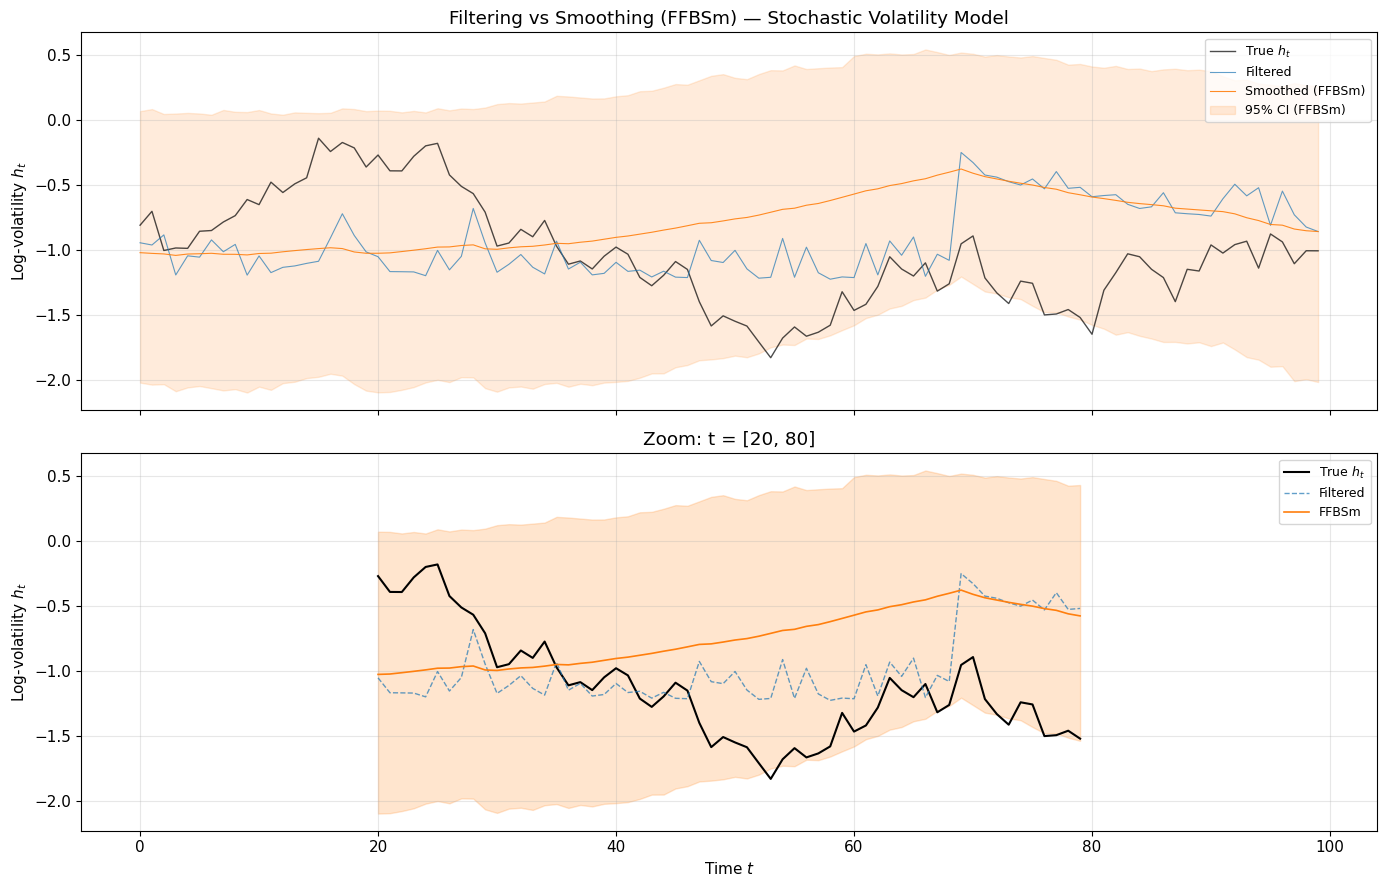

In [7]:
# Plot: h_true vs filtered vs smoothed (FFBSm) with confidence intervals
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
t_axis = np.arange(T)

ax = axes[0]
ax.plot(t_axis, h_true, 'k-', lw=1.0, alpha=0.7, label='True $h_t$')
ax.plot(t_axis, filtered_mean[:, 0], 'C0-', lw=0.8, alpha=0.7, label='Filtered')
ax.plot(t_axis, results_ffbsm.smoothed_mean[:, 0], 'C1-', lw=0.8, alpha=0.9, label='Smoothed (FFBSm)')

if 0.025 in results_ffbsm.smoothed_quantiles and 0.975 in results_ffbsm.smoothed_quantiles:
    q025 = results_ffbsm.smoothed_quantiles[0.025][:, 0]
    q975 = results_ffbsm.smoothed_quantiles[0.975][:, 0]
    ax.fill_between(t_axis, q025, q975, alpha=0.15, color='C1', label='95% CI (FFBSm)')

ax.set_ylabel('Log-volatility $h_t$')
ax.set_title('Filtering vs Smoothing (FFBSm) — Stochastic Volatility Model')
ax.legend(loc='upper right', fontsize=9)

# Zoom on subset
zoom_start, zoom_end = 20, 80
ax = axes[1]
idx = slice(zoom_start, zoom_end)
ax.plot(t_axis[idx], h_true[idx], 'k-', lw=1.5, label='True $h_t$')
ax.plot(t_axis[idx], filtered_mean[idx, 0], 'C0--', lw=1.0, alpha=0.7, label='Filtered')
ax.plot(t_axis[idx], results_ffbsm.smoothed_mean[idx, 0], 'C1-', lw=1.2, label='FFBSm')
if 0.025 in results_ffbsm.smoothed_quantiles:
    ax.fill_between(t_axis[idx], q025[idx], q975[idx], alpha=0.2, color='C1')
ax.set_xlabel('Time $t$')
ax.set_ylabel('Log-volatility $h_t$')
ax.set_title(f'Zoom: t = [{zoom_start}, {zoom_end}]')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()


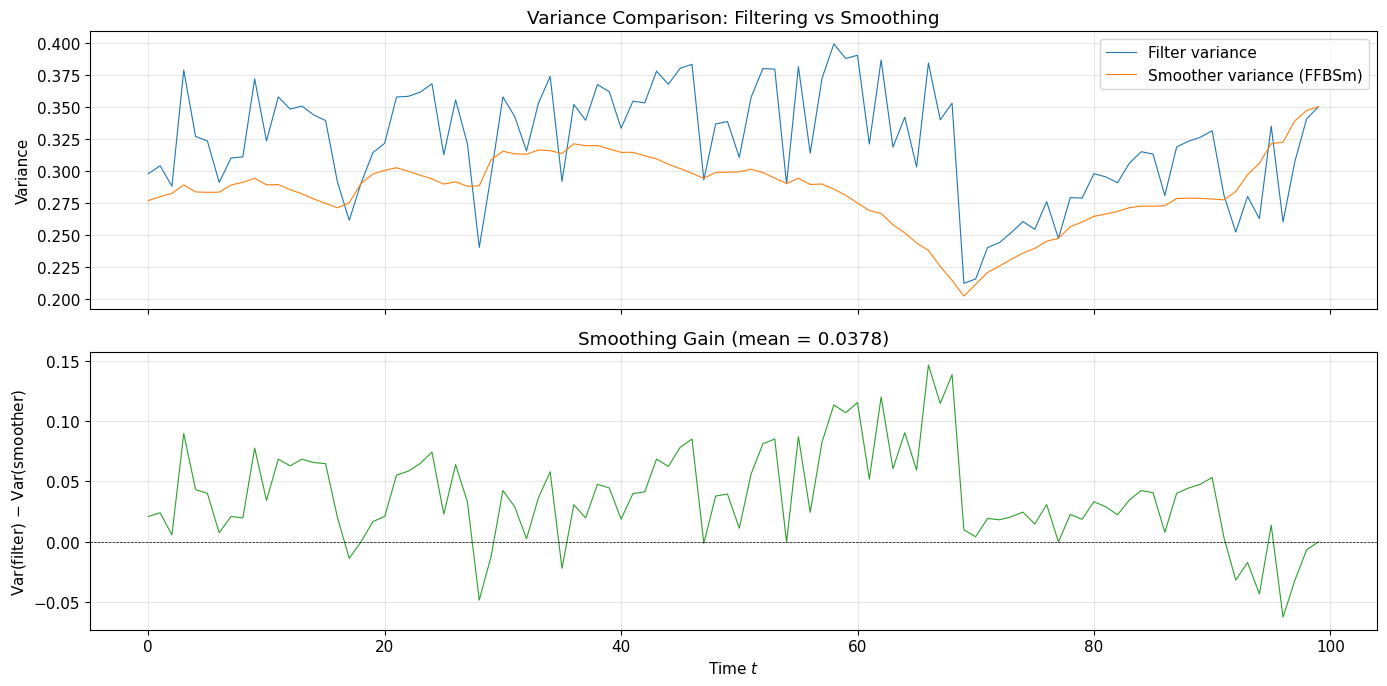

Mean filter variance:   0.3222
Mean smoother variance: 0.2843
Mean smoothing gain:    0.0378
Fraction of timesteps with positive gain: 86.0%

Variance reduction confirmed: Var[h_t|y_{1:T}] <= Var[h_t|y_{1:t}]


In [8]:
# Plot: Smoothing gain — variance reduction over time
filter_var = filtered_cov[:, 0, 0]
smoother_var = results_ffbsm.smoothed_cov[:, 0, 0]
smoothing_gain = filter_var - smoother_var

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
ax.plot(t_axis, filter_var, 'C0-', lw=0.8, label='Filter variance')
ax.plot(t_axis, smoother_var, 'C1-', lw=0.8, label='Smoother variance (FFBSm)')
ax.set_ylabel('Variance')
ax.set_title('Variance Comparison: Filtering vs Smoothing')
ax.legend()

ax = axes[1]
ax.plot(t_axis, smoothing_gain, 'C2-', lw=0.8)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('Time $t$')
ax.set_ylabel('Var(filter) $-$ Var(smoother)')
ax.set_title(f'Smoothing Gain (mean = {np.mean(smoothing_gain):.4f})')

plt.tight_layout()
plt.show()

print(f"Mean filter variance:   {np.mean(filter_var):.4f}")
print(f"Mean smoother variance: {np.mean(smoother_var):.4f}")
print(f"Mean smoothing gain:    {np.mean(smoothing_gain):.4f}")
print(f"Fraction of timesteps with positive gain: {np.mean(smoothing_gain > 0):.1%}")

# Verify: smoother variance should be smaller on average
assert np.mean(smoother_var) < np.mean(filter_var), \
    "Smoother variance should be less than filter variance on average"
print("\nVariance reduction confirmed: Var[h_t|y_{1:T}] <= Var[h_t|y_{1:t}]")


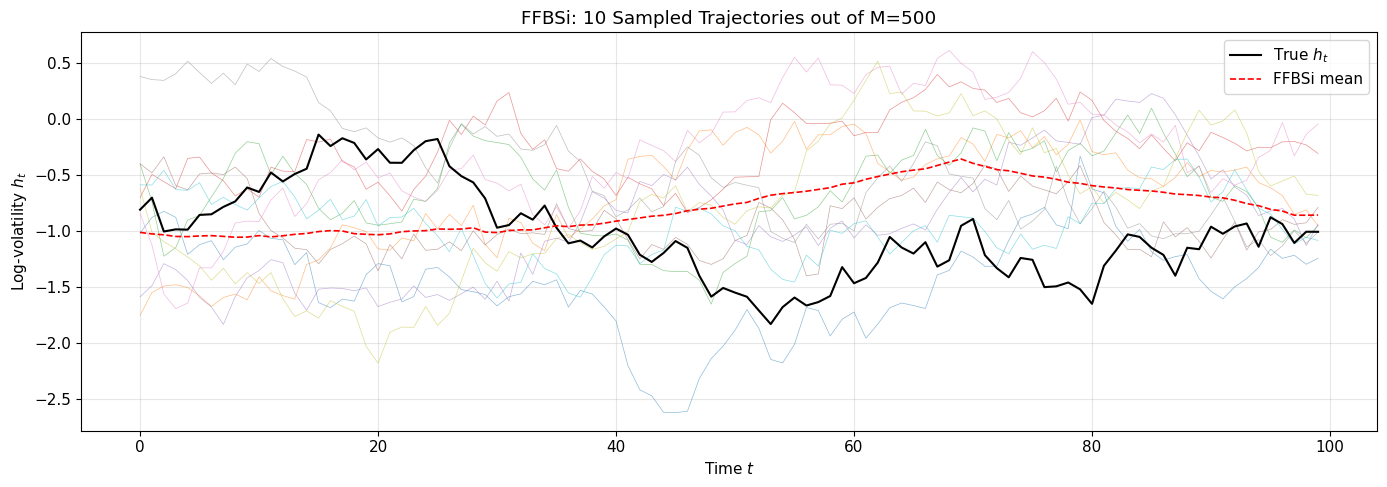

In [9]:
# Plot: 10 sampled trajectories from FFBSi
fig, ax = plt.subplots(figsize=(14, 5))

n_show = 10
for m in range(n_show):
    ax.plot(t_axis, results_ffbsi.trajectories[m, :, 0], lw=0.5, alpha=0.5)

ax.plot(t_axis, h_true, 'k-', lw=1.5, label='True $h_t$')
ax.plot(t_axis, results_ffbsi.smoothed_mean[:, 0], 'r--', lw=1.2, label='FFBSi mean')

ax.set_xlabel('Time $t$')
ax.set_ylabel('Log-volatility $h_t$')
ax.set_title(f'FFBSi: {n_show} Sampled Trajectories out of M={M}')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [10]:
# Comparison table: RMSE filter vs FFBSm vs FFBSi
mae_filter = np.mean(np.abs(filtered_mean[:, 0] - h_true))
mae_ffbsm = np.mean(np.abs(results_ffbsm.smoothed_mean[:, 0] - h_true))
mae_ffbsi = np.mean(np.abs(results_ffbsi.smoothed_mean[:, 0] - h_true))

mean_var_filter = np.mean(filtered_cov[:, 0, 0])
mean_var_ffbsm = np.mean(results_ffbsm.smoothed_cov[:, 0, 0])
mean_var_ffbsi = np.mean(results_ffbsi.smoothed_cov[:, 0, 0])

comparison = pd.DataFrame({
    'Method': ['Filter', 'FFBSm', 'FFBSi'],
    'RMSE': [rmse_filter, rmse_ffbsm, rmse_ffbsi],
    'MAE': [mae_filter, mae_ffbsm, mae_ffbsi],
    'Mean Variance': [mean_var_filter, mean_var_ffbsm, mean_var_ffbsi],
    'Var Reduction (%)': [
        0.0,
        (1 - mean_var_ffbsm / mean_var_filter) * 100,
        (1 - mean_var_ffbsi / mean_var_filter) * 100,
    ],
    'Time (s)': [elapsed_filter, elapsed_ffbsm, elapsed_ffbsi],
    'Complexity': ['O(T*N)', 'O(T*N^2)', f'O(T*N*M), M={M}'],
})
print("=== Filter vs Smoother Comparison ===")
print(comparison.to_string(index=False))

# Verify: smoothed estimates have lower variance (theoretical guarantee)
assert mean_var_ffbsm < mean_var_filter, "FFBSm variance should be less than filter"
assert mean_var_ffbsi < mean_var_filter, "FFBSi variance should be less than filter"
print("\nBoth smoothers achieve lower posterior variance than the filter.")
print(f"Smoothed estimates RMSE is {'lower' if rmse_ffbsm < rmse_filter else 'comparable to'} filtered RMSE.")


=== Filter vs Smoother Comparison ===
Method     RMSE      MAE  Mean Variance  Var Reduction (%)  Time (s)      Complexity
Filter 0.527237 0.438840       0.322153           0.000000  0.013402          O(T*N)
 FFBSm 0.607894 0.525394       0.284330          11.740527 12.095840        O(T*N^2)
 FFBSi 0.614032 0.531050       0.284378          11.725787  3.051958 O(T*N*M), M=500

Both smoothers achieve lower posterior variance than the filter.
Smoothed estimates RMSE is comparable to filtered RMSE.


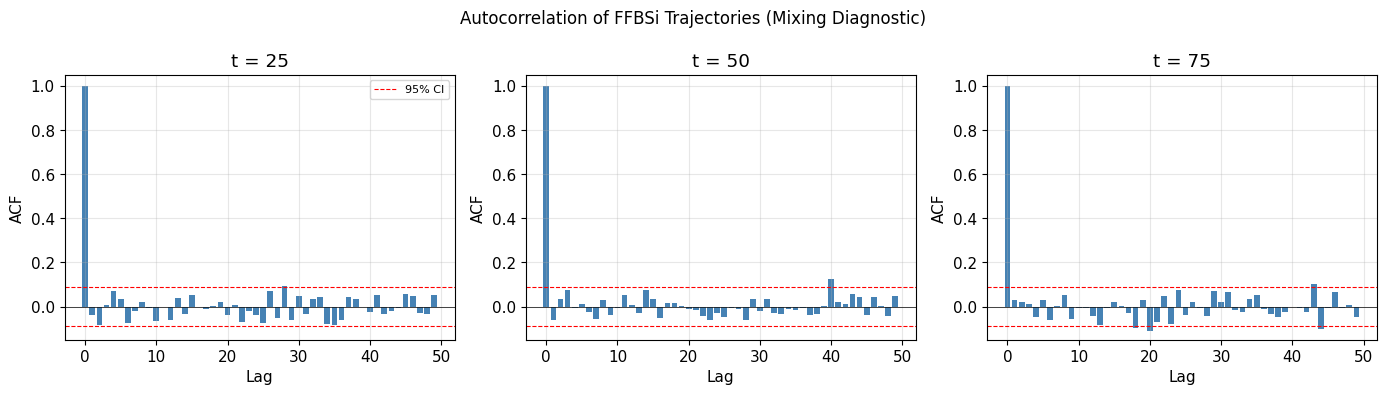

In [11]:
# Plot: Autocorrelation of FFBSi trajectories (mixing diagnostic)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

time_points = [T // 4, T // 2, 3 * T // 4]

for ax, t_pt in zip(axes, time_points):
    samples = results_ffbsi.trajectories[:, t_pt, 0]  # (M,)
    max_lag = min(50, M // 4)
    acf = np.zeros(max_lag)
    mean_s = np.mean(samples)
    var_s = np.var(samples)
    if var_s > 0:
        for lag in range(max_lag):
            acf[lag] = np.mean((samples[:M-lag] - mean_s) * (samples[lag:] - mean_s)) / var_s

    ax.bar(range(max_lag), acf, color='steelblue', width=0.8)
    ax.axhline(0, color='k', lw=0.5)
    ax.axhline(1.96 / np.sqrt(M), color='r', ls='--', lw=0.8, label='95% CI')
    ax.axhline(-1.96 / np.sqrt(M), color='r', ls='--', lw=0.8)
    ax.set_xlabel('Lag')
    ax.set_ylabel('ACF')
    ax.set_title(f't = {t_pt}')
    ax.set_ylim(-0.15, 1.05)
    if ax == axes[0]:
        ax.legend(fontsize=8)

plt.suptitle('Autocorrelation of FFBSi Trajectories (Mixing Diagnostic)', fontsize=12)
plt.tight_layout()
plt.show()


## Conclusions: FFBSm vs FFBSi

| Aspect | FFBSm | FFBSi |
|--------|-------|-------|
| **Output** | Smoothed weights $w_{t\|T}^{(i)}$ | M smoothed trajectories $\tilde{h}_{0:T}^{(m)}$ |
| **Complexity** | $O(T \cdot N^2)$ | $O(T \cdot N \cdot M)$ |
| **Memory** | Same particles, new weights | M full trajectories |
| **Accuracy** | Exact (given particles) | Monte Carlo approximation |
| **Use cases** | Marginal smoothing $E[f(h_t) \mid y_{1:T}]$ | Joint smoothing, path-dependent functionals |

### Key takeaways

1. **Both smoothers reduce posterior variance** compared to filtering, as guaranteed by the
   smoothing inequality $\text{Var}[h_t \mid y_{1:T}] \leq \text{Var}[h_t \mid y_{1:t}]$.
2. **FFBSm** is exact given the filtering particles, but has $O(N^2)$ cost per timestep which is
   expensive for large N.
3. **FFBSi** is more flexible (generates full trajectories), but introduces additional Monte Carlo
   error. The quality depends on M.
4. **FFBSi trajectories are approximately independent** — the autocorrelation plots show rapid
   mixing, which is a desirable property.
5. For **marginal smoothing** (estimating $E[h_t \mid y_{1:T}]$ separately for each $t$), FFBSm
   is preferred.
6. For **joint/path smoothing** (e.g., path-dependent functionals or MCMC within Gibbs), FFBSi
   is preferred.
